# Weka testing

To analyse the feature importance of onchain dataset WEKA tool was utilised
this contains the code that created the weka testing file

result

1. normal_total_cnt     (InfoGain: 0.1765)
2. active_span_min      (InfoGain: 0.1458)
3. uniq_peers_cnt       (InfoGain: 0.1439)
4. burst_max_tx_5m      (InfoGain: 0.1397)
5. normal_sent_cnt      (InfoGain: 0.127)

Remove one feature ablation study was conducted

result

* removed active_span_min since it actually improved AUC when removed
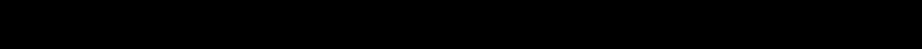
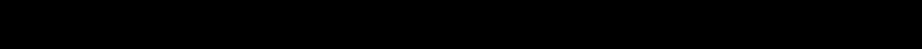

In [3]:
import pandas as pd
import os

df = pd.read_parquet("../data/processed/chain/balanced_label_days.parquet")

features = [
    "normal_sent_cnt",
    "normal_recv_cnt",
    "normal_total_cnt",
    "eth_sent_sum",
    "eth_recv_sum",
    "eth_net_flow",
    "uniq_peers_cnt",
    "sessions_cnt",
    "active_span_min",
    "burst_max_tx_5m"
]

In [5]:
print("\nDaily Date Range:", df['day'].min(), "-", df['day'].max())


Daily Date Range: 2017-03-15 - 2021-11-01


In [4]:
import arff

df["is_anomalous"] = df["is_anomalous"].astype(str)

attributes = [(col, "NUMERIC") for col in features]
attributes.append(("is_anomalous", ["0", "1"]))

arff_data = {
    "relation": "daily_anomaly_nominal",
    "attributes": attributes,
    "data": df[features + ["is_anomalous"]].values.tolist()
}

with open("../data/weka/anomaly_daily_nominal.arff", "w") as f:
    arff.dump(arff_data, f)

print("ARFF created with nominal class")


ARFF created with nominal class
